In [2]:
%run "02.1_utls.ipynb"

(5410, 36)
(4328, 34)
(1082, 34)
PotentialFraud
0    3923
1     405
Name: count, dtype: int64
PotentialFraud
0    981
1    101
Name: count, dtype: int64


In [3]:
# Import required libraries for machine learning and data analysis
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve, roc_auc_score, precision_recall_curve,auc  # For model evaluation metrics
import matplotlib.pyplot as plt  # For plotting visualizations
import lightgbm as lgb  # For LightGBM classifier model
import pickle



In [4]:
x_train.columns

Index(['IP_Claim_Count', 'IP_Benf_Count', 'Avg_IP_InscClaimAmtReimbursed',
       'Avg_IP_DeductibleAmtPaid', 'Avg_IP_Number_of_Days_in_Hospital',
       'Avg_IP_Claim_Days', 'Avg_IP_Unique_Disease_Count',
       'Avg_IP_Unique_Treatment_Count', 'OP_Claim_Count', 'OP_Benf_Count',
       'Avg_OP_InscClaimAmtReimbursed', 'Avg_OP_DeductibleAmtPaid',
       'Avg_OP_Claim_Days', 'Avg_OP_Unique_Disease_Count',
       'Avg_OP_Unique_Treatment_Count', 'Total_Beneficiaries',
       'RenalDisease_Count', 'Alzheimer_Count', 'HeartFailure_Count',
       'KidneyDisease_Count', 'Cancer_Count', 'Pulmonary_Count',
       'Depression_Count', 'Diabetes_Count', 'IschemicHeart_Count',
       'Osteoporosis_Count', 'RheumatoidArthritis_Count', 'Stroke_Count',
       'Avg_PartA_Months', 'Avg_PartB_Months_Mode', 'Avg_IP_Reimbursement',
       'Avg_IP_Deductible', 'Avg_OP_Reimbursement', 'Avg_OP_Deductible'],
      dtype='str')

In [5]:
x_test.columns==x_train.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True])

In [6]:
y_train

3090    0
3462    0
3446    0
839     0
921     0
       ..
5352    0
4640    0
846     0
1641    0
2535    0
Name: PotentialFraud, Length: 4328, dtype: int64

### Training LightGbm Regression Model

In [7]:
# Initialize LightGBM classifier with specific hyperparameters
lgb_estimate = lgb.LGBMClassifier(n_estimators= 70,  # Number of boosting rounds/trees
                                max_depth = 5,  # Maximum depth of each tree
                                n_leaves = 12,  # Maximum number of leaves in a tree
                                learning_rate = 0.05,  # Learning rate (shrinkage)
                                random_state = 42,  # Random seed for reproducibility
                                class_weight={0:0.1,1:0.9},
                                verbosity = -1)  # Suppress training output messages
                        
# Train the LightGBM model on the training data
lgb_estimate.fit(x_train,y_train)
# Make predictions on the test set
y_pred = lgb_estimate.predict(x_test)
# Get predicted probabilities for the positive class (fraud)
y_prob = lgb_estimate.predict_proba(x_test)[:, 1]
# Print classification metrics report showing precision, recall, f1-score
print("*****Classification Rport********")
print(classification_report(y_test,y_pred))
# Print confusion matrix showing true/false positives and negatives
print("**** Confusion Matrix ***********")
print(confusion_matrix(y_test,y_pred))

*****Classification Rport********
              precision    recall  f1-score   support

           0       0.98      0.89      0.94       981
           1       0.45      0.84      0.58       101

    accuracy                           0.89      1082
   macro avg       0.71      0.87      0.76      1082
weighted avg       0.93      0.89      0.90      1082

**** Confusion Matrix ***********
[[876 105]
 [ 16  85]]


In [8]:
lgb_estimate.feature_names_in_

array(['IP_Claim_Count', 'IP_Benf_Count', 'Avg_IP_InscClaimAmtReimbursed',
       'Avg_IP_DeductibleAmtPaid', 'Avg_IP_Number_of_Days_in_Hospital',
       'Avg_IP_Claim_Days', 'Avg_IP_Unique_Disease_Count',
       'Avg_IP_Unique_Treatment_Count', 'OP_Claim_Count', 'OP_Benf_Count',
       'Avg_OP_InscClaimAmtReimbursed', 'Avg_OP_DeductibleAmtPaid',
       'Avg_OP_Claim_Days', 'Avg_OP_Unique_Disease_Count',
       'Avg_OP_Unique_Treatment_Count', 'Total_Beneficiaries',
       'RenalDisease_Count', 'Alzheimer_Count', 'HeartFailure_Count',
       'KidneyDisease_Count', 'Cancer_Count', 'Pulmonary_Count',
       'Depression_Count', 'Diabetes_Count', 'IschemicHeart_Count',
       'Osteoporosis_Count', 'RheumatoidArthritis_Count', 'Stroke_Count',
       'Avg_PartA_Months', 'Avg_PartB_Months_Mode',
       'Avg_IP_Reimbursement', 'Avg_IP_Deductible',
       'Avg_OP_Reimbursement', 'Avg_OP_Deductible'], dtype='<U33')

In [9]:
# Calculate accuracy score on the training data
Train_score = accuracy_score(y_train,lgb_estimate.predict(x_train))
# Calculate accuracy score on the test data
Test_score = accuracy_score(y_test,y_pred)
# Print training set accuracy
print("Train_score: ", Train_score)
# Print test set accuracy
print("Test_score: ", Test_score)
# Calculate and print the overfitting percentage (difference between train and test accuracy)
print("over_fiting: ", round((Train_score - Test_score)*100,3))

Train_score:  0.9108133086876156
Test_score:  0.8881700554528651
over_fiting:  2.264


### ROC and PR Curves

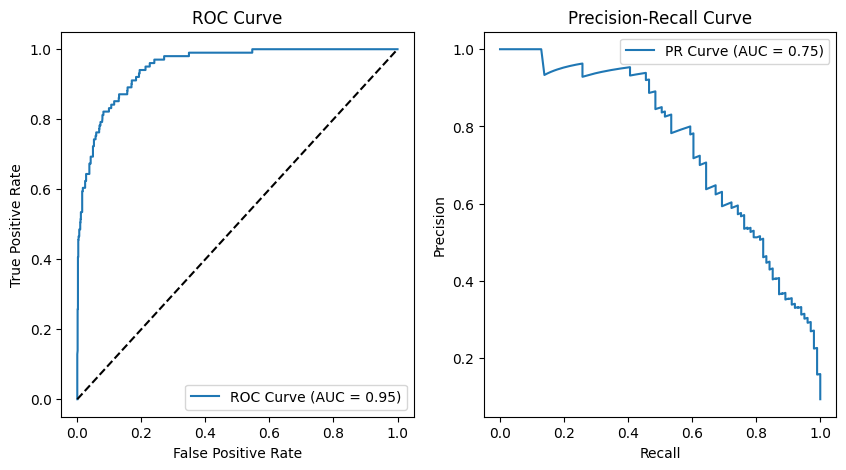

In [10]:
# Calculate false positive rate and true positive rate for ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
# Calculate area under the ROC curve
roc_auc = auc(fpr, tpr)

# Calculate precision and recall values for PR curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
# Calculate area under the Precision-Recall curve
pr_auc = auc(recall, precision)

# Create a figure with two subplots for ROC and PR curves
plt.figure(figsize=(10, 5))
# Plot ROC Curve in the first subplot
plt.subplot(1, 2, 1)
# Plot the ROC curve with AUC score
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
# Plot the diagonal line representing random classifier performance
plt.plot([0, 1], [0, 1], 'k--')
# Label the x-axis
plt.xlabel('False Positive Rate')
# Label the y-axis
plt.ylabel('True Positive Rate')
# Set the title of the plot
plt.title('ROC Curve')
# Add legend to the plot
plt.legend()

# Plot Precision-Recall Curve in the second subplot
plt.subplot(1, 2, 2)
# Plot the PR curve with AUC score
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
# Label the x-axis
plt.xlabel('Recall')
# Label the y-axis
plt.ylabel('Precision')
# Set the title of the plot
plt.title('Precision-Recall Curve')
# Add legend to the plot
plt.legend()
# Display the plots
plt.show()

In [11]:
with open("../Models/lgbm_desired.pkl", "wb") as f:
    pickle.dump(lgb_estimate,f)